In [1]:
# ==============================
# STEP 1: MOUNT GOOGLE DRIVE
# ==============================

# Base paths
DATA_PATH = "data"
MODEL_PATH = "models"

import os
os.makedirs(MODEL_PATH, exist_ok=True)

print("Data path:", DATA_PATH)
print("Model path:", MODEL_PATH)


Data path: data
Model path: models


In [2]:
# ==============================
# STEP 2: IMPORT LIBRARIES
# ==============================

import pandas as pd
import numpy as np
import json

from datetime import datetime
from collections import defaultdict

# ML
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error

import lightgbm as lgb
import joblib

# Visualization (later use)
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


In [3]:
# ==============================
# STEP 3: LOAD MARKET SHARE DATA
# ==============================

market_share = pd.read_csv(
    f"{DATA_PATH}/market_share_history.csv"
)

market_share.head()


,product,year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,AH,2022,21.97,22.12,21.68,21.83,22.00,21.67,22.19,22.23,22.56,21.91,22.00,22.23
1,AH,2023,22.14,22.02,21.70,21.52,21.47,21.80,22.19,22.38,21.66,21.83,21.64,21.94
2,AH,2024,21.67,22.07,22.09,21.33,22.12,21.80,21.66,21.61,21.62,21.82,21.80,21.68
3,AH,2025,21.52,22.26,21.69,21.72,21.79,22.11,21.39,21.75,21.84,21.57,21.58,21.47
4,CL,2022,8.55,8.43,9.01,9.12,9.49,9.74,9.26,9.04,9.57,8.99,8.55,8.40


In [4]:
# ==============================
# STEP 4: MELT MARKET SHARE TO MONTHLY
# ==============================

month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "Jun": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
}

market_long = market_share.melt(
    id_vars=["product", "year"],
    value_vars=list(month_map.keys()),
    var_name="month",
    value_name="market_share"
)

market_long["month_num"] = market_long["month"].map(month_map)
market_long["date"] = pd.to_datetime(
    dict(year=market_long.year, month=market_long.month_num, day=1)
)

market_long = market_long.sort_values(["product", "date"]).reset_index(drop=True)

market_long.head()


,product,year,month,market_share,month_num,date
0,AH,2022,Jan,21.97,1,2022-01-01
1,AH,2022,Feb,22.12,2,2022-02-01
2,AH,2022,Mar,21.68,3,2022-03-01
3,AH,2022,Apr,21.83,4,2022-04-01
4,AH,2022,May,22.00,5,2022-05-01


In [5]:
# ==============================
# STEP 5: CREATE LAG FEATURES
# ==============================

for lag in range(1, 7):
    market_long[f"share_lag_{lag}"] = (
        market_long
        .groupby("product")["market_share"]
        .shift(lag)
    )

market_long.head(10)


,product,year,month,market_share,month_num,date,share_lag_1,share_lag_2,share_lag_3,share_lag_4,share_lag_5,share_lag_6
0,AH,2022,Jan,21.97,1,2022-01-01,NaN,NaN,NaN,NaN,NaN,NaN
1,AH,2022,Feb,22.12,2,2022-02-01,21.97,NaN,NaN,NaN,NaN,NaN
2,AH,2022,Mar,21.68,3,2022-03-01,22.12,21.97,NaN,NaN,NaN,NaN
3,AH,2022,Apr,21.83,4,2022-04-01,21.68,22.12,21.97,NaN,NaN,NaN
4,AH,2022,May,22.00,5,2022-05-01,21.83,21.68,22.12,21.97,NaN,NaN
5,AH,2022,Jun,21.67,6,2022-06-01,22.00,21.83,21.68,22.12,21.97,NaN
6,AH,2022,Jul,22.19,7,2022-07-01,21.67,22.00,21.83,21.68,22.12,21.97
7,AH,2022,Aug,22.23,8,2022-08-01,22.19,21.67,22.00,21.83,21.68,22.12
8,AH,2022,Sep,22.56,9,2022-09-01,22.23,22.19,21.67,22.00,21.83,21.68
9,AH,2022,Oct,21.91,10,2022-10-01,22.56,22.23,22.19,21.67,22.00,21.83


In [6]:
# ==============================
# STEP 6: LOAD EXTERNAL SIGNALS
# ==============================

external = pd.read_csv(
    f"{DATA_PATH}/external_signals.csv"
)

external["date"] = pd.to_datetime(
    dict(year=external.year, month=external.month, day=1)
)

external.head()


,year,month,avg_temp_f,heating_degree_days,cooling_degree_days,housing_starts_k,building_permits_k,gdp_growth_pct,consumer_confidence,energy_price_idx,interest_rate_pct,date
0,2022,1,29.3,1072.0,0.0,1299.0,1422.0,0.82,103.3,109.4,3.78,2022-01-01
1,2022,2,29.5,1066.0,0.0,1315.0,1394.0,0.44,102.9,114.9,3.75,2022-02-01
2,2022,3,43.4,647.0,0.0,1485.0,1614.0,1.38,102.8,94.6,3.86,2022-03-01
3,2022,4,56.1,266.0,0.0,1569.0,1722.0,0.56,93.9,108.3,3.62,2022-04-01
4,2022,5,65.8,0.0,23.0,1611.0,1807.0,0.72,94.0,112.2,3.93,2022-05-01


In [7]:
# ==============================
# STEP 7: LOAD REGULATORY DATA
# ==============================

regulatory = pd.read_csv(
    f"{DATA_PATH}/regulatory_timeline.csv"
)

regulatory["announcement_date"] = pd.to_datetime(regulatory["announcement_date"])
regulatory["effective_date"] = pd.to_datetime(regulatory["effective_date"])

regulatory.head()


,regulation_id,effective_date,announcement_date,regulation_type,products_affected,impact_description,impact_magnitude,compliance_deadline
0,REG-2022-001,2022-07-01,2021-12-01,labeling_requirement,"AH,CL,CN,FN,HP",Updated EnergyGuide labels required,Low,2022-07-01
1,REG-2022-002,2022-10-01,2022-02-15,efficiency_standard,HP,Cold climate performance disclosure,Medium,2022-10-01
2,REG-2023-001,2023-01-01,2022-06-15,efficiency_standard,"HP,CN",SEER2 measurement method transition,Medium,2023-01-01
3,REG-2023-002,2023-04-01,2022-09-01,emissions_limit,FN,Updated NOx emissions limits,Medium,2023-04-01
4,REG-2024-001,2024-01-01,2023-04-15,efficiency_standard,AH,Minimum SEER2 14 for air handlers,Medium,2024-01-01


In [8]:
# ==============================
# STEP 8: LOAD NEWS CORPUS
# ==============================

with open(f"{DATA_PATH}/news_corpus.json", "r") as f:
    news_json = json.load(f)

news_df = pd.DataFrame(news_json["articles"])

news_df["date"] = pd.to_datetime(news_df["date"])
news_df["year"] = news_df["date"].dt.year
news_df["month"] = news_df["date"].dt.month

news_df.head()


,id,date,source,headline,body,entities,sentiment,relevance_score,tags,year,month
0,NEWS-2023-001,2023-06-05,Contracting Business,EPA Finalizes New SEER Standards for 2023,Industry sources report that epa finalizes new...,[],neutral,0.90,[regulation],2023,6
1,NEWS-2023-002,2023-12-09,HPAC Engineering,York Announces New Packaged Unit Line for 2025,Industry sources report that york announces ne...,"[York, Packaged Unit]",neutral,0.81,[product_launch],2023,12
2,NEWS-2023-003,2023-05-01,Contracting Business,Housing Starts Rise to 15-Month High,Industry sources report that housing starts ri...,[],positive,0.76,[housing],2023,5
3,NEWS-2025-004,2025-11-05,HVAC Industry Weekly,EPA Finalizes New SEER Standards for 2024,Industry sources report that epa finalizes new...,[],neutral,1.03,[regulation],2025,11
4,NEWS-2023-005,2023-01-25,HPAC Engineering,Refrigerant Phase-Out Timeline Accelerated,Industry sources report that refrigerant phase...,[],negative,0.83,[regulation],2023,1


In [9]:
# ==============================
# STEP 9: SENTIMENT ENCODING
# ==============================

# Map sentiment to numeric values
sentiment_map = {
    "positive": 1,
    "neutral": 0,
    "negative": -1
}

news_df["sentiment_score"] = news_df["sentiment"].map(sentiment_map)

news_df[["sentiment", "sentiment_score"]].head()


,sentiment,sentiment_score
0,neutral,0
1,neutral,0
2,positive,1
3,neutral,0
4,negative,-1


In [10]:
# ==============================
# STEP 10: EXPLODE TAGS
# ==============================

news_exploded = news_df.explode("tags").copy()

news_exploded["tags"] = news_exploded["tags"].str.lower()

news_exploded[["headline", "tags"]].head(10)


,headline,tags
0,EPA Finalizes New SEER Standards for 2023,regulation
1,York Announces New Packaged Unit Line for 2025,product_launch
2,Housing Starts Rise to 15-Month High,housing
3,EPA Finalizes New SEER Standards for 2024,regulation
4,Refrigerant Phase-Out Timeline Accelerated,regulation
5,Heat Pump Adoption Accelerates in Northern Mar...,technology
6,York Expands Manufacturing Capacity by 11%,capacity
7,Rheem Faces Supply Chain Challenges,supply_chain
8,Carrier Cuts Prices on Condenser Models,pricing
9,Refrigerant Phase-Out Timeline Accelerated,regulation


In [11]:
# ==============================
# STEP 11: MAP ARTICLES TO PRODUCTS
# ==============================

def map_article_to_product(row):
    text = (row["headline"] + " " + row["body"]).lower()

    if "heat pump" in text:
        return "HP"
    elif "furnace" in text:
        return "FN"
    elif "air handler" in text:
        return "AH"
    elif "condenser" in text:
        return "CN"
    elif "packaged" in text or "cooler" in text:
        return "CL"
    else:
        return None  # global / unclear impact

news_exploded["product"] = news_exploded.apply(map_article_to_product, axis=1)

news_exploded["product"].value_counts(dropna=False)


product
HP    70
FN    49
CN    49
AH    40
CL    32
Name: count, dtype: int64

In [12]:
# ==============================
# STEP 12: FILTER PRODUCT-SPECIFIC NEWS
# ==============================

news_prod = news_exploded.dropna(subset=["product"]).copy()

news_prod.head()


,id,date,source,headline,body,entities,sentiment,relevance_score,tags,year,month,sentiment_score,product
0,NEWS-2023-001,2023-06-05,Contracting Business,EPA Finalizes New SEER Standards for 2023,Industry sources report that epa finalizes new...,[],neutral,0.90,regulation,2023,6,0,AH
1,NEWS-2023-002,2023-12-09,HPAC Engineering,York Announces New Packaged Unit Line for 2025,Industry sources report that york announces ne...,"[York, Packaged Unit]",neutral,0.81,product_launch,2023,12,0,CL
2,NEWS-2023-003,2023-05-01,Contracting Business,Housing Starts Rise to 15-Month High,Industry sources report that housing starts ri...,[],positive,0.76,housing,2023,5,1,AH
3,NEWS-2025-004,2025-11-05,HVAC Industry Weekly,EPA Finalizes New SEER Standards for 2024,Industry sources report that epa finalizes new...,[],neutral,1.03,regulation,2025,11,0,CN
4,NEWS-2023-005,2023-01-25,HPAC Engineering,Refrigerant Phase-Out Timeline Accelerated,Industry sources report that refrigerant phase...,[],negative,0.83,regulation,2023,1,-1,CL


In [13]:
# ==============================
# STEP 13: MONTHLY AGGREGATION
# ==============================

# Create base monthly aggregation
monthly_news = (
    news_prod
    .groupby(["product", "year", "month"])
    .apply(lambda x: pd.Series({
        "news_volume": x["relevance_score"].sum(),
        "avg_sentiment": np.average(
            x["sentiment_score"],
            weights=x["relevance_score"]
        )
    }))
    .reset_index()
)

monthly_news.head()


C:\Users\rupes\AppData\Local\Temp\ipykernel_22708\221994547.py:9: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: pd.Series({


,product,year,month,news_volume,avg_sentiment
0,AH,2022,1,2.19,-0.242009
1,AH,2022,3,0.71,0.000000
2,AH,2022,8,0.50,0.000000
3,AH,2022,10,0.88,0.000000
4,AH,2023,1,0.68,-1.000000


In [14]:
# ==============================
# STEP 14: TAG-LEVEL FEATURES
# ==============================

tag_features = (
    news_prod
    .groupby(["product", "year", "month", "tags"])
    .agg(tag_weighted_count=("relevance_score", "sum"))
    .reset_index()
)

# Pivot tags into columns
tag_pivot = tag_features.pivot_table(
    index=["product", "year", "month"],
    columns="tags",
    values="tag_weighted_count",
    fill_value=0
).reset_index()

tag_pivot.head()


tags,product,year,month,capacity,construction,earnings,energy,housing,market,pricing,product_launch,regulation,supply_chain,technology
0,AH,2022,1,0.0,0.76,0.60,0.0,0.0,0.00,0.0,0.0,0.00,0.83,0.0
1,AH,2022,3,0.0,0.00,0.00,0.0,0.0,0.71,0.0,0.0,0.00,0.00,0.0
2,AH,2022,8,0.0,0.00,0.00,0.5,0.0,0.00,0.0,0.0,0.00,0.00,0.0
3,AH,2022,10,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.88,0.00,0.0
4,AH,2023,1,0.0,0.00,0.68,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0


In [15]:
# ==============================
# STEP 15: FINAL NEWS FEATURE TABLE
# ==============================

news_features = pd.merge(
    monthly_news,
    tag_pivot,
    on=["product", "year", "month"],
    how="left"
)

news_features.head()


,product,year,month,news_volume,avg_sentiment,capacity,construction,earnings,energy,housing,market,pricing,product_launch,regulation,supply_chain,technology
0,AH,2022,1,2.19,-0.242009,0.0,0.76,0.60,0.0,0.0,0.00,0.0,0.0,0.00,0.83,0.0
1,AH,2022,3,0.71,0.000000,0.0,0.00,0.00,0.0,0.0,0.71,0.0,0.0,0.00,0.00,0.0
2,AH,2022,8,0.50,0.000000,0.0,0.00,0.00,0.5,0.0,0.00,0.0,0.0,0.00,0.00,0.0
3,AH,2022,10,0.88,0.000000,0.0,0.00,0.00,0.0,0.0,0.00,0.0,0.0,0.88,0.00,0.0
4,AH,2023,1,0.68,-1.000000,0.0,0.00,0.68,0.0,0.0,0.00,0.0,0.0,0.00,0.00,0.0


In [16]:
news_features.to_csv(
    f"{DATA_PATH}/news_monthly_features.csv",
    index=False
)


In [17]:
# ==============================
# STEP 16: BASE MARKET SHARE TABLE
# ==============================

model_df = market_long.copy()

# Keep only useful columns
model_df = model_df[
    [
        "product", "year", "month_num", "date",
        "market_share",
        "share_lag_1", "share_lag_2", "share_lag_3",
        "share_lag_4", "share_lag_5", "share_lag_6"
    ]
]

model_df.head()


,product,year,month_num,date,market_share,share_lag_1,share_lag_2,share_lag_3,share_lag_4,share_lag_5,share_lag_6
0,AH,2022,1,2022-01-01,21.97,NaN,NaN,NaN,NaN,NaN,NaN
1,AH,2022,2,2022-02-01,22.12,21.97,NaN,NaN,NaN,NaN,NaN
2,AH,2022,3,2022-03-01,21.68,22.12,21.97,NaN,NaN,NaN,NaN
3,AH,2022,4,2022-04-01,21.83,21.68,22.12,21.97,NaN,NaN,NaN
4,AH,2022,5,2022-05-01,22.00,21.83,21.68,22.12,21.97,NaN,NaN


In [18]:
print("model_df columns:")
print(model_df.columns.tolist())

print("\nnews_features columns:")
print(news_features.columns.tolist())


model_df columns:
['product', 'year', 'month_num', 'date', 'market_share', 'share_lag_1', 'share_lag_2', 'share_lag_3', 'share_lag_4', 'share_lag_5', 'share_lag_6']

news_features columns:
['product', 'year', 'month', 'news_volume', 'avg_sentiment', 'capacity', 'construction', 'earnings', 'energy', 'housing', 'market', 'pricing', 'product_launch', 'regulation', 'supply_chain', 'technology']


In [19]:
# ==============================
# FIX: ALIGN MONTH COLUMN
# ==============================

news_features = news_features.rename(
    columns={"month": "month_num"}
)

news_features.columns


Index(['product', 'year', 'month_num', 'news_volume', 'avg_sentiment',
       'capacity', 'construction', 'earnings', 'energy', 'housing', 'market',
       'pricing', 'product_launch', 'regulation', 'supply_chain',
       'technology'],
      dtype='object')

In [20]:
# ==============================
# STEP 17: MERGE NEWS FEATURES
# ==============================

model_df = model_df.merge(
    news_features,
    on=["product", "year", "month_num"],
    how="left"
)

# Fill months with no news as 0 impact
news_cols = model_df.columns.difference(
    [
        "product", "year", "month_num", "date",
        "market_share",
        "share_lag_1", "share_lag_2", "share_lag_3",
        "share_lag_4", "share_lag_5", "share_lag_6"
    ]
)

model_df[news_cols] = model_df[news_cols].fillna(0)

model_df.head()


,product,year,month_num,date,market_share,share_lag_1,share_lag_2,share_lag_3,share_lag_4,share_lag_5,share_lag_6,news_volume,avg_sentiment,capacity,construction,earnings,energy,housing,market,pricing,product_launch,regulation,supply_chain,technology
0,AH,2022,1,2022-01-01,21.97,NaN,NaN,NaN,NaN,NaN,NaN,2.19,-0.242009,0.0,0.76,0.6,0.0,0.0,0.00,0.0,0.0,0.0,0.83,0.0
1,AH,2022,2,2022-02-01,22.12,21.97,NaN,NaN,NaN,NaN,NaN,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0
2,AH,2022,3,2022-03-01,21.68,22.12,21.97,NaN,NaN,NaN,NaN,0.71,0.000000,0.0,0.00,0.0,0.0,0.0,0.71,0.0,0.0,0.0,0.00,0.0
3,AH,2022,4,2022-04-01,21.83,21.68,22.12,21.97,NaN,NaN,NaN,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0
4,AH,2022,5,2022-05-01,22.00,21.83,21.68,22.12,21.97,NaN,NaN,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0


In [21]:
# ==============================
# STEP 18: MERGE EXTERNAL SIGNALS
# ==============================

external_small = external.copy()

# Select only strong signals
external_small = external_small[
    [
        "date",
        "housing_starts_k",
        "consumer_confidence",
        "energy_price_idx",
        "interest_rate_pct"
    ]
]

# Merge
model_df = model_df.merge(
    external_small,
    on="date",
    how="left"
)

# Create lags (3 months lead effect)
for col in [
    "housing_starts_k",
    "consumer_confidence",
    "energy_price_idx",
    "interest_rate_pct"
]:
    model_df[f"{col}_lag3"] = (
        model_df
        .groupby("product")[col]
        .shift(3)
    )

# Drop raw (unlagged) columns
model_df.drop(
    columns=[
        "housing_starts_k",
        "consumer_confidence",
        "energy_price_idx",
        "interest_rate_pct"
    ],
    inplace=True
)

model_df.head()


,product,year,month_num,date,market_share,share_lag_1,share_lag_2,share_lag_3,share_lag_4,share_lag_5,share_lag_6,news_volume,avg_sentiment,capacity,construction,earnings,energy,housing,market,pricing,product_launch,regulation,supply_chain,technology,housing_starts_k_lag3,consumer_confidence_lag3,energy_price_idx_lag3,interest_rate_pct_lag3
0,AH,2022,1,2022-01-01,21.97,NaN,NaN,NaN,NaN,NaN,NaN,2.19,-0.242009,0.0,0.76,0.6,0.0,0.0,0.00,0.0,0.0,0.0,0.83,0.0,NaN,NaN,NaN,NaN
1,AH,2022,2,2022-02-01,22.12,21.97,NaN,NaN,NaN,NaN,NaN,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,NaN,NaN,NaN,NaN
2,AH,2022,3,2022-03-01,21.68,22.12,21.97,NaN,NaN,NaN,NaN,0.71,0.000000,0.0,0.00,0.0,0.0,0.0,0.71,0.0,0.0,0.0,0.00,0.0,NaN,NaN,NaN,NaN
3,AH,2022,4,2022-04-01,21.83,21.68,22.12,21.97,NaN,NaN,NaN,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,1299.0,103.3,109.4,3.78
4,AH,2022,5,2022-05-01,22.00,21.83,21.68,22.12,21.97,NaN,NaN,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,1315.0,102.9,114.9,3.75


In [22]:
# ==============================
# STEP 19: REGULATORY FEATURE ENGINEERING
# ==============================

# Encode impact magnitude
impact_map = {"Low": 1, "Medium": 2, "High": 3}
regulatory["impact_encoded"] = regulatory["impact_magnitude"].map(impact_map)

def regulatory_features(row):
    product = row["product"]
    date = row["date"]

    relevant_regs = regulatory[
        regulatory["products_affected"].str.contains(product)
    ]

    if relevant_regs.empty:
        return pd.Series({
            "months_since_announcement": 0,
            "months_until_effective": 0,
            "reg_impact": 0,
            "reg_active": 0
        })

    # Find nearest regulation (by announcement)
    relevant_regs = relevant_regs.copy()
    relevant_regs["months_since_ann"] = (
        (date - relevant_regs["announcement_date"]).dt.days // 30
    )

    closest = relevant_regs.iloc[
        relevant_regs["months_since_ann"].abs().argsort().iloc[0]
    ]

    months_since_announcement = max(0, closest["months_since_ann"])
    months_until_effective = (
        (closest["effective_date"] - date).days // 30
    )

    return pd.Series({
        "months_since_announcement": months_since_announcement,
        "months_until_effective": months_until_effective,
        "reg_impact": closest["impact_encoded"],
        "reg_active": int(date >= closest["effective_date"])
    })

reg_features = model_df.apply(regulatory_features, axis=1)

model_df = pd.concat([model_df, reg_features], axis=1)

model_df.head()


,product,year,month_num,date,market_share,share_lag_1,share_lag_2,share_lag_3,share_lag_4,share_lag_5,share_lag_6,news_volume,avg_sentiment,capacity,construction,earnings,energy,housing,market,pricing,product_launch,regulation,supply_chain,technology,housing_starts_k_lag3,consumer_confidence_lag3,energy_price_idx_lag3,interest_rate_pct_lag3,months_since_announcement,months_until_effective,reg_impact,reg_active
0,AH,2022,1,2022-01-01,21.97,NaN,NaN,NaN,NaN,NaN,NaN,2.19,-0.242009,0.0,0.76,0.6,0.0,0.0,0.00,0.0,0.0,0.0,0.83,0.0,NaN,NaN,NaN,NaN,1,6,1,0
1,AH,2022,2,2022-02-01,22.12,21.97,NaN,NaN,NaN,NaN,NaN,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,NaN,NaN,NaN,NaN,2,5,1,0
2,AH,2022,3,2022-03-01,21.68,22.12,21.97,NaN,NaN,NaN,NaN,0.71,0.000000,0.0,0.00,0.0,0.0,0.0,0.71,0.0,0.0,0.0,0.00,0.0,NaN,NaN,NaN,NaN,3,4,1,0
3,AH,2022,4,2022-04-01,21.83,21.68,22.12,21.97,NaN,NaN,NaN,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,1299.0,103.3,109.4,3.78,4,3,1,0
4,AH,2022,5,2022-05-01,22.00,21.83,21.68,22.12,21.97,NaN,NaN,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,1315.0,102.9,114.9,3.75,5,2,1,0


In [23]:
# ==============================
# STEP 20: CREATE TARGET VARIABLE
# ==============================

model_df["target_share_t_plus_3"] = (
    model_df
    .groupby("product")["market_share"]
    .shift(-3)
)

model_df.head()


,product,year,month_num,date,market_share,share_lag_1,share_lag_2,share_lag_3,share_lag_4,share_lag_5,share_lag_6,news_volume,avg_sentiment,capacity,construction,earnings,energy,housing,market,pricing,product_launch,regulation,supply_chain,technology,housing_starts_k_lag3,consumer_confidence_lag3,energy_price_idx_lag3,interest_rate_pct_lag3,months_since_announcement,months_until_effective,reg_impact,reg_active,target_share_t_plus_3
0,AH,2022,1,2022-01-01,21.97,NaN,NaN,NaN,NaN,NaN,NaN,2.19,-0.242009,0.0,0.76,0.6,0.0,0.0,0.00,0.0,0.0,0.0,0.83,0.0,NaN,NaN,NaN,NaN,1,6,1,0,21.83
1,AH,2022,2,2022-02-01,22.12,21.97,NaN,NaN,NaN,NaN,NaN,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,NaN,NaN,NaN,NaN,2,5,1,0,22.00
2,AH,2022,3,2022-03-01,21.68,22.12,21.97,NaN,NaN,NaN,NaN,0.71,0.000000,0.0,0.00,0.0,0.0,0.0,0.71,0.0,0.0,0.0,0.00,0.0,NaN,NaN,NaN,NaN,3,4,1,0,21.67
3,AH,2022,4,2022-04-01,21.83,21.68,22.12,21.97,NaN,NaN,NaN,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,1299.0,103.3,109.4,3.78,4,3,1,0,22.19
4,AH,2022,5,2022-05-01,22.00,21.83,21.68,22.12,21.97,NaN,NaN,0.00,0.000000,0.0,0.00,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.00,0.0,1315.0,102.9,114.9,3.75,5,2,1,0,22.23


In [24]:
# ==============================
# STEP 21: DROP INVALID ROWS
# ==============================

model_df_clean = model_df.dropna(
    subset=[
        "share_lag_1", "share_lag_2", "share_lag_3",
        "share_lag_4", "share_lag_5", "share_lag_6",
        "target_share_t_plus_3"
    ]
).reset_index(drop=True)

print("Final training rows:", model_df_clean.shape[0])
model_df_clean.head()


Final training rows: 195


,product,year,month_num,date,market_share,share_lag_1,share_lag_2,share_lag_3,share_lag_4,share_lag_5,share_lag_6,news_volume,avg_sentiment,capacity,construction,earnings,energy,housing,market,pricing,product_launch,regulation,supply_chain,technology,housing_starts_k_lag3,consumer_confidence_lag3,energy_price_idx_lag3,interest_rate_pct_lag3,months_since_announcement,months_until_effective,reg_impact,reg_active,target_share_t_plus_3
0,AH,2022,7,2022-07-01,22.19,21.67,22.00,21.83,21.68,22.12,21.97,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1569.0,93.9,108.3,3.62,7,0,1,1,21.91
1,AH,2022,8,2022-08-01,22.23,22.19,21.67,22.00,21.83,21.68,22.12,0.50,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1611.0,94.0,112.2,3.93,8,-2,1,1,22.00
2,AH,2022,9,2022-09-01,22.56,22.23,22.19,21.67,22.00,21.83,21.68,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1603.0,103.2,104.0,3.81,0,16,2,0,22.23
3,AH,2022,10,2022-10-01,21.91,22.56,22.23,22.19,21.67,22.00,21.83,0.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.88,0.0,0.0,1560.0,108.6,96.8,3.78,0,15,2,0,22.14
4,AH,2022,11,2022-11-01,22.00,21.91,22.56,22.23,22.19,21.67,22.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1434.0,106.3,90.6,4.13,0,14,2,0,22.02


In [25]:
# ==============================
# STEP 22: SAVE FEATURE TABLE
# ==============================

model_df_clean.to_csv(
    f"{DATA_PATH}/ps4_feature_table.csv",
    index=False
)

print("Feature table saved successfully.")


Feature table saved successfully.


Model Training

In [26]:
# ==============================
# STEP 23: PREPARE TRAINING DATA
# ==============================

# Copy clean feature table
df = model_df_clean.copy()

# Drop non-feature columns
TARGET = "target_share_t_plus_3"

DROP_COLS = [
    "date",
    "market_share",   # current value (avoid leakage)
    TARGET
]

FEATURES = [c for c in df.columns if c not in DROP_COLS]

X = df[FEATURES]
y = df[TARGET]

print("Number of features:", len(FEATURES))
print("Target:", TARGET)


Number of features: 30
Target: target_share_t_plus_3


In [27]:
# ==============================
# STEP 24: TIME-BASED SPLIT
# ==============================

# Sort by time
df = df.sort_values("date")

# Use last ~20% as validation
split_date = df["date"].quantile(0.8)

train_idx = df["date"] <= split_date
val_idx   = df["date"] > split_date

X_train, X_val = X.loc[train_idx], X.loc[val_idx]
y_train, y_val = y.loc[train_idx], y.loc[val_idx]

print("Train samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])


Train samples: 160
Validation samples: 35


In [28]:
# ==============================
# STEP 25: TRAIN LIGHTGBM MODEL (FIXED)
# ==============================

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=32,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Ensure all features are numeric for LightGBM
for c in X_train.columns:
    if X_train[c].dtype == 'object':
        X_train[c] = X_train[c].astype('category').cat.codes
        X_val[c] = X_val[c].astype('category').cat.codes
lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse"
)


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: product: object

In [29]:
# ==============================
# STEP 29: ENCODE PRODUCT FEATURE
# ==============================

from sklearn.preprocessing import LabelEncoder

# Encode product as numeric category
le = LabelEncoder()
df["product_encoded"] = le.fit_transform(df["product"])

# Drop original string column
df = df.drop(columns=["product"])

df.head()


,year,month_num,date,market_share,share_lag_1,share_lag_2,share_lag_3,share_lag_4,share_lag_5,share_lag_6,news_volume,avg_sentiment,capacity,construction,earnings,energy,housing,market,pricing,product_launch,regulation,supply_chain,technology,housing_starts_k_lag3,consumer_confidence_lag3,energy_price_idx_lag3,interest_rate_pct_lag3,months_since_announcement,months_until_effective,reg_impact,reg_active,target_share_t_plus_3,product_encoded
0,2022,7,2022-07-01,22.19,21.67,22.00,21.83,21.68,22.12,21.97,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,1569.0,93.9,108.3,3.62,7,0,1,1,21.91,0
117,2022,7,2022-07-01,17.86,18.61,18.31,18.48,19.19,19.59,19.78,2.26,0.000000,0.0,0.0,0.0,0.0,0.0,1.26,0.0,0.0,1.0,0.0,0.00,1569.0,93.9,108.3,3.62,0,9,2,0,19.07,3
78,2022,7,2022-07-01,18.00,18.10,18.21,18.45,18.03,17.71,17.68,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,1569.0,93.9,108.3,3.62,0,6,2,0,17.81,2
156,2022,7,2022-07-01,32.69,31.87,31.99,32.12,32.09,32.15,32.01,1.19,0.571429,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,1.19,1569.0,93.9,108.3,3.62,0,6,2,0,32.21,4
39,2022,7,2022-07-01,9.26,9.74,9.49,9.12,9.01,8.43,8.55,0.00,0.000000,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.00,1569.0,93.9,108.3,3.62,7,0,1,1,8.99,1


In [30]:
# ==============================
# STEP 30: REBUILD FEATURES & TARGET
# ==============================

TARGET = "target_share_t_plus_3"

DROP_COLS = [
    "date",
    "market_share",
    TARGET
]

FEATURES = [c for c in df.columns if c not in DROP_COLS]

X = df[FEATURES]
y = df[TARGET]

print("Features used:")
print(FEATURES)


Features used:
['year', 'month_num', 'share_lag_1', 'share_lag_2', 'share_lag_3', 'share_lag_4', 'share_lag_5', 'share_lag_6', 'news_volume', 'avg_sentiment', 'capacity', 'construction', 'earnings', 'energy', 'housing', 'market', 'pricing', 'product_launch', 'regulation', 'supply_chain', 'technology', 'housing_starts_k_lag3', 'consumer_confidence_lag3', 'energy_price_idx_lag3', 'interest_rate_pct_lag3', 'months_since_announcement', 'months_until_effective', 'reg_impact', 'reg_active', 'product_encoded']


In [31]:
# ==============================
# STEP 31: TIME-BASED SPLIT (AGAIN)
# ==============================

df = df.sort_values("date")

split_date = df["date"].quantile(0.8)

train_idx = df["date"] <= split_date
val_idx   = df["date"] > split_date

X_train, X_val = X.loc[train_idx], X.loc[val_idx]
y_train, y_val = y.loc[train_idx], y.loc[val_idx]

print("Train:", X_train.shape)
print("Val:", X_val.shape)


Train: (160, 30)
Val: (35, 30)


In [32]:
# ==============================
# STEP 32: TRAIN LIGHTGBM (FINAL)
# ==============================

lgb_model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
    num_leaves=32,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

# Ensure all features are numeric for LightGBM
for c in X_train.columns:
    if X_train[c].dtype == 'object':
        X_train[c] = X_train[c].astype('category').cat.codes
        X_val[c] = X_val[c].astype('category').cat.codes
lgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    eval_metric="rmse"
)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000499 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 571
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 21
[LightGBM] [Info] Start training from score 20.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

,boosting_type,'gbdt'
,num_leaves,32
,max_depth,5
,learning_rate,0.03
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [33]:
# ==============================
# STEP 33: EVALUATION (VERSION-SAFE)
# ==============================

from sklearn.metrics import mean_squared_error
import numpy as np

y_pred = lgb_model.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)

print(f"Validation RMSE (t+3 months): {rmse:.4f}")


Validation RMSE (t+3 months): 0.2969


In [34]:
# Pick one sample from validation set
sample_idx = X_val.index[0]

base_row = X_val.loc[[sample_idx]].copy()
base_pred = lgb_model.predict(base_row)[0]

print("Base prediction:", base_pred)


Base prediction: 21.584197587435632


In [35]:
# Look at news-related columns only
news_cols = [c for c in base_row.columns if c.startswith(("pricing", "regulation", "technology", "news", "avg_sentiment"))]

base_row[news_cols]


,news_volume,avg_sentiment,pricing,regulation,technology
32,0.0,0.0,0.0,0.0,0.0


In [36]:
# Create a what-if copy
what_if_row = base_row.copy()

# Artificially increase pricing-related news
for col in what_if_row.columns:
    if "pricing" in col:
        what_if_row[col] = what_if_row[col] * 2 + 1

what_if_pred = lgb_model.predict(what_if_row)[0]

print("Base prediction:", base_pred)
print("What-if (pricing news ↑):", what_if_pred)
print("Change:", what_if_pred - base_pred)


Base prediction: 21.584197587435632
What-if (pricing news ↑): 21.584197587435632
Change: 0.0


In [37]:
reg_test_row = base_row.copy()

reg_test_row["reg_active"] = 1
reg_test_row["reg_impact"] = 3   # High impact
reg_test_row["months_since_announcement"] = 1
reg_test_row["months_until_effective"] = 0

reg_pred = lgb_model.predict(reg_test_row)[0]

print("Base prediction:", base_pred)
print("Regulation shock prediction:", reg_pred)
print("Change:", reg_pred - base_pred)


Base prediction: 21.584197587435632
Regulation shock prediction: 21.424588612273382
Change: -0.15960897516225003


In [38]:
macro_test_row = base_row.copy()

macro_test_row["housing_starts_k_lag3"] *= 1.3

macro_pred = lgb_model.predict(macro_test_row)[0]

print("Base prediction:", base_pred)
print("Housing boom prediction:", macro_pred)
print("Change:", macro_pred - base_pred)


Base prediction: 21.584197587435632
Housing boom prediction: 21.645093494030576
Change: 0.06089590659494348


In [39]:
noise_row = base_row.copy()

noise_cols = noise_row.columns
noise = np.random.normal(0, 0.05, size=len(noise_cols))
noise_row.iloc[0] += noise

noise_pred = lgb_model.predict(noise_row)[0]

print("Base prediction:", base_pred)
print("Noisy input prediction:", noise_pred)
print("Change:", noise_pred - base_pred)


Base prediction: 21.584197587435632
Noisy input prediction: 18.732762537952606
Change: -2.851435049483026


C:\Users\rupes\AppData\Local\Temp\ipykernel_22708\2859811077.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2025.067273913585' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  noise_row.iloc[0] += noise
C:\Users\rupes\AppData\Local\Temp\ipykernel_22708\2859811077.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2.88032854895701' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  noise_row.iloc[0] += noise
C:\Users\rupes\AppData\Local\Temp\ipykernel_22708\2859811077.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '-0.045695400343370544' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  noise_row.iloc[0] += noise
C:\U

In [40]:
# ==============================
# STEP 34: INSTALL & IMPORT SHAP
# ==============================

!pip install shap

import shap


   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   ---------------------------------------- 548.0/548.0 kB 4.6 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   --------------- ------------------------ 1.0/2.7 MB 5.6 MB/s eta 0:00:01
   ------------------------------ --------- 2.1/2.7 MB 4.9 MB/s eta 0:00:01
   ---------------------------------------- 2.7/2.7 MB 4.5 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   - -------------------------------------- 1.0/38.1 MB 6.3 MB/s eta 0:00:06
   -- ------------------------------------- 2.6/38.1 MB 6.3 MB/s eta 0:00:06
   ---- ----------------------------------- 3.9/38.1 MB 6.3 MB/s eta 0:00:06
   ----- ---------------------------------- 5.2/38.1 MB 6.5 MB/s eta 0:00:06
   ------- -------------------------------- 6.8/38.1 MB 6.6 MB/s eta 0:00:05
   -------- ------------------------------- 8.1/38.1 MB 6.5 MB/s eta 0:00:05
   --------- -------------

d:\commonenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [41]:
# ==============================
# STEP 35: CREATE SHAP EXPLAINER
# ==============================

explainer = shap.TreeExplainer(lgb_model)

# Use validation data for explanations
shap_values = explainer.shap_values(X_val)


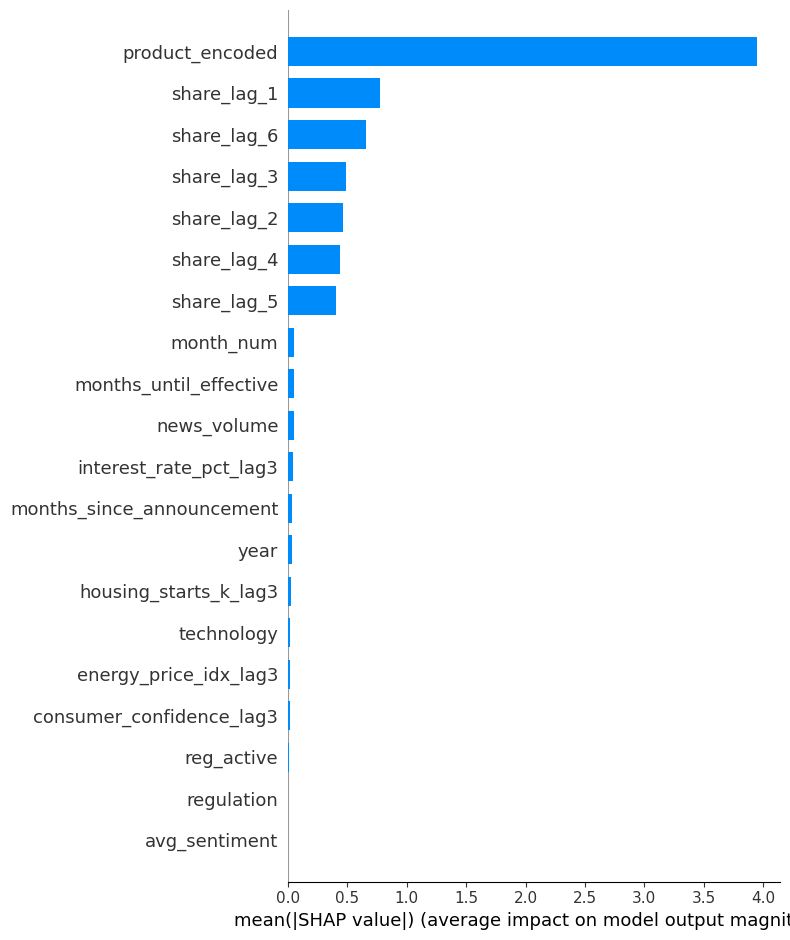

In [42]:
# ==============================
# STEP 36: GLOBAL FEATURE IMPORTANCE
# ==============================

shap.summary_plot(
    shap_values,
    X_val,
    plot_type="bar",
    show=True
)


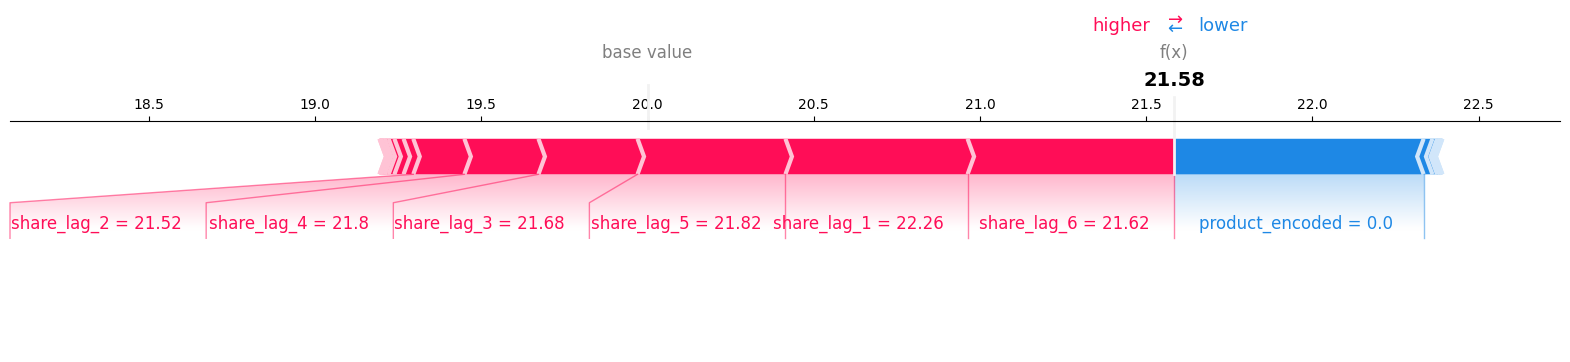

In [43]:
# ==============================
# STEP 37: LOCAL EXPLANATION
# ==============================

# Pick one validation sample
sample_idx = X_val.index[0]

shap.force_plot(
    explainer.expected_value,
    shap_values[X_val.index.get_loc(sample_idx)],
    X_val.loc[sample_idx],
    matplotlib=True
)


In [44]:
# ==============================
# STEP 38: GROUP FEATURE CONTRIBUTIONS
# ==============================

feature_groups = {
    "Market Momentum": [c for c in X.columns if "share_lag" in c],
    "News Signals": [c for c in X.columns if c not in [
        "product_encoded", "months_since_announcement",
        "months_until_effective", "reg_impact", "reg_active"
    ] and not c.startswith("share_lag")],
    "Regulation": ["months_since_announcement", "months_until_effective", "reg_impact", "reg_active"],
    "Macro": [c for c in X.columns if "lag3" in c]
}

group_contrib = {}

for group, cols in feature_groups.items():
    idxs = [X.columns.get_loc(c) for c in cols if c in X.columns]
    group_contrib[group] = shap_values[:, idxs].sum(axis=1).mean()

group_contrib


{'Market Momentum': np.float64(0.1720861004584861),
 'News Signals': np.float64(0.04111658619315106),
 'Regulation': np.float64(0.023031486792476605),
 'Macro': np.float64(-0.015065089598997182)}

In [45]:
# ==============================
# STEP 39: CREATE PREDICTION TABLE
# ==============================

val_results = X_val.copy()
val_results["actual_share"] = y_val
val_results["predicted_share"] = y_pred
val_results["predicted_change"] = val_results["predicted_share"] - df.loc[val_idx, "market_share"].values

val_results.head()


,year,month_num,share_lag_1,share_lag_2,share_lag_3,share_lag_4,share_lag_5,share_lag_6,news_volume,avg_sentiment,capacity,construction,earnings,energy,housing,market,pricing,product_launch,regulation,supply_chain,technology,housing_starts_k_lag3,consumer_confidence_lag3,energy_price_idx_lag3,interest_rate_pct_lag3,months_since_announcement,months_until_effective,reg_impact,reg_active,product_encoded,actual_share,predicted_share,predicted_change
32,2025,3,22.26,21.52,21.68,21.80,21.82,21.62,0.00,0.000000,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,1238.0,110.9,98.9,5.03,0,10,3,0,0,22.11,21.584198,-0.105802
188,2025,3,32.11,32.09,32.62,32.38,32.10,32.41,1.59,-0.031447,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.82,0.0,0.77,1238.0,110.9,98.9,5.03,0,10,3,0,4,32.39,32.550465,0.260465
149,2025,3,19.39,20.42,19.17,19.23,18.88,17.91,0.76,-1.000000,0.0,0.76,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,1238.0,110.9,98.9,5.03,11,-2,3,1,3,17.81,18.088368,-1.161632
71,2025,3,8.53,8.12,8.71,8.48,9.17,9.12,0.00,0.000000,0.0,0.00,0.00,0.0,0.0,0.0,0.0,0.00,0.00,0.0,0.00,1238.0,110.9,98.9,5.03,0,10,3,0,1,9.15,9.243982,0.543982
110,2025,3,17.72,17.85,17.82,18.11,18.03,18.94,2.40,-0.283333,0.0,0.00,0.68,0.0,0.0,0.0,0.0,1.72,0.00,0.0,0.00,1238.0,110.9,98.9,5.03,0,10,3,0,2,18.55,18.601026,0.521026


In [46]:
# ==============================
# STEP 40: ALERT LOGIC
# ==============================

ALERT_CHANGE_THRESHOLD = 1.0     # %
RISK_SHARE_THRESHOLD = 18.0      # example risk level

val_results["alert"] = (
    (val_results["predicted_change"].abs() > ALERT_CHANGE_THRESHOLD) |
    (val_results["predicted_share"] < RISK_SHARE_THRESHOLD)
)

alerts = val_results[val_results["alert"]]

alerts[["predicted_share", "predicted_change"]].head()


,predicted_share,predicted_change
149,18.088368,-1.161632
71,9.243982,0.543982
72,9.015206,0.195206
150,17.957340,-1.132660
190,32.460295,10.670295


In [47]:
# ==============================
# STEP 41: ATTACH TOP DRIVERS
# ==============================

def top_drivers(row_idx, top_n=3):
    shap_row = shap_values[row_idx]
    top_idx = np.argsort(np.abs(shap_row))[-top_n:]
    return X.columns[top_idx].tolist()

alerts["top_drivers"] = [
    top_drivers(X_val.index.get_loc(idx))
    for idx in alerts.index
]

alerts[["predicted_share", "predicted_change", "top_drivers"]].head()


C:\Users\rupes\AppData\Local\Temp\ipykernel_22708\3397704865.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  alerts["top_drivers"] = [


,predicted_share,predicted_change,top_drivers
149,18.088368,-1.161632,"[share_lag_4, share_lag_1, product_encoded]"
71,9.243982,0.543982,"[share_lag_6, share_lag_1, product_encoded]"
72,9.015206,0.195206,"[share_lag_6, share_lag_1, product_encoded]"
150,17.957340,-1.132660,"[share_lag_4, share_lag_1, product_encoded]"
190,32.460295,10.670295,"[share_lag_2, share_lag_1, product_encoded]"


In [50]:
# ==============================
# SAVE LIGHTGBM MODEL
# ==============================

import joblib
import os

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

model_path = f"{MODEL_DIR}/lgb_market_share_t_plus_3.pkl"

joblib.dump(lgb_model, model_path)

print(f"Model saved successfully at:\n{model_path}")


Model saved successfully at:
models/lgb_market_share_t_plus_3.pkl


In [51]:
# ==============================
# SAVE LABEL ENCODER
# ==============================

encoder_path = f"{MODEL_DIR}/product_label_encoder.pkl"
joblib.dump(le, encoder_path)

print(f"LabelEncoder saved at:\n{encoder_path}")


LabelEncoder saved at:
models/product_label_encoder.pkl


In [52]:
# ==============================
# SAVE FEATURE LIST
# ==============================

features_path = f"{MODEL_DIR}/model_features.pkl"
joblib.dump(FEATURES, features_path)

print(f"Feature list saved at:\n{features_path}")


Feature list saved at:
models/model_features.pkl


#Other Evaluation Matrix and Visualisation

In [53]:
# ==============================
# LOAD MODEL & ARTIFACTS
# ==============================

import joblib
import pandas as pd
import numpy as np

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

MODEL_DIR = "models"
DATA_PATH = "data"

# Load model
lgb_model = joblib.load(f"{MODEL_DIR}/lgb_market_share_t_plus_3.pkl")

# Load feature list
FEATURES = joblib.load(f"{MODEL_DIR}/model_features.pkl")

print("Model and features loaded.")


Model and features loaded.


In [54]:
df = pd.read_csv(f"{DATA_PATH}/ps4_feature_table.csv")
df["date"] = pd.to_datetime(df["date"])

df.head()


,product,year,month_num,date,market_share,share_lag_1,share_lag_2,share_lag_3,share_lag_4,share_lag_5,share_lag_6,news_volume,avg_sentiment,capacity,construction,earnings,energy,housing,market,pricing,product_launch,regulation,supply_chain,technology,housing_starts_k_lag3,consumer_confidence_lag3,energy_price_idx_lag3,interest_rate_pct_lag3,months_since_announcement,months_until_effective,reg_impact,reg_active,target_share_t_plus_3
0,AH,2022,7,2022-07-01,22.19,21.67,22.00,21.83,21.68,22.12,21.97,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1569.0,93.9,108.3,3.62,7,0,1,1,21.91
1,AH,2022,8,2022-08-01,22.23,22.19,21.67,22.00,21.83,21.68,22.12,0.50,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1611.0,94.0,112.2,3.93,8,-2,1,1,22.00
2,AH,2022,9,2022-09-01,22.56,22.23,22.19,21.67,22.00,21.83,21.68,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1603.0,103.2,104.0,3.81,0,16,2,0,22.23
3,AH,2022,10,2022-10-01,21.91,22.56,22.23,22.19,21.67,22.00,21.83,0.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.88,0.0,0.0,1560.0,108.6,96.8,3.78,0,15,2,0,22.14
4,AH,2022,11,2022-11-01,22.00,21.91,22.56,22.23,22.19,21.67,22.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1434.0,106.3,90.6,4.13,0,14,2,0,22.02


In [55]:
import joblib

MODEL_DIR = "models"

# Load the saved LabelEncoder
le = joblib.load(f"{MODEL_DIR}/product_label_encoder.pkl")

print("LabelEncoder loaded successfully.")


LabelEncoder loaded successfully.


In [56]:
# Recreate product_encoded exactly as during training
df["product_encoded"] = le.transform(df["product"])

df.head()


,product,year,month_num,date,market_share,share_lag_1,share_lag_2,share_lag_3,share_lag_4,share_lag_5,share_lag_6,news_volume,avg_sentiment,capacity,construction,earnings,energy,housing,market,pricing,product_launch,regulation,supply_chain,technology,housing_starts_k_lag3,consumer_confidence_lag3,energy_price_idx_lag3,interest_rate_pct_lag3,months_since_announcement,months_until_effective,reg_impact,reg_active,target_share_t_plus_3,product_encoded
0,AH,2022,7,2022-07-01,22.19,21.67,22.00,21.83,21.68,22.12,21.97,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1569.0,93.9,108.3,3.62,7,0,1,1,21.91,0
1,AH,2022,8,2022-08-01,22.23,22.19,21.67,22.00,21.83,21.68,22.12,0.50,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1611.0,94.0,112.2,3.93,8,-2,1,1,22.00,0
2,AH,2022,9,2022-09-01,22.56,22.23,22.19,21.67,22.00,21.83,21.68,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1603.0,103.2,104.0,3.81,0,16,2,0,22.23,0
3,AH,2022,10,2022-10-01,21.91,22.56,22.23,22.19,21.67,22.00,21.83,0.88,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.88,0.0,0.0,1560.0,108.6,96.8,3.78,0,15,2,0,22.14,0
4,AH,2022,11,2022-11-01,22.00,21.91,22.56,22.23,22.19,21.67,22.00,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,1434.0,106.3,90.6,4.13,0,14,2,0,22.02,0


In [57]:
TARGET = "target_share_t_plus_3"

X = df[FEATURES]
y = df[TARGET]

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)


Feature matrix shape: (195, 30)
Target vector shape: (195,)


In [58]:
split_date = df["date"].quantile(0.8)

X_val = X[df["date"] > split_date]
y_val = y[df["date"] > split_date]

print("Validation samples:", X_val.shape[0])


Validation samples: 35


In [59]:
y_pred = lgb_model.predict(X_val)

mse = mean_squared_error(y_val, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("Model Performance (Validation)")
print("------------------------------")
print(f"MSE  : {mse:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")


Model Performance (Validation)
------------------------------
MSE  : 0.0881
RMSE : 0.2969
MAE  : 0.2291
R²   : 0.9985


In [60]:
# ==============================
# ADD MAPE METRIC
# ==============================

import numpy as np

mape = np.mean(np.abs((y_val - y_pred) / y_val)) * 100

print(f"MAPE : {mape:.2f}%")


MAPE : 1.29%


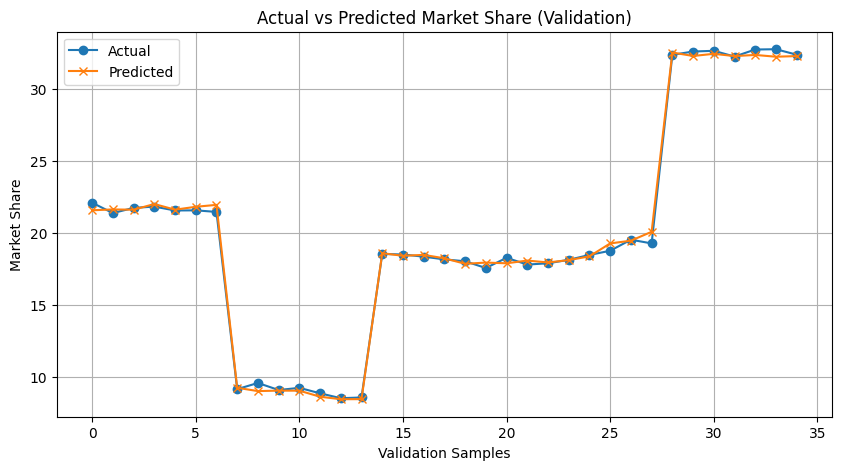

In [61]:
plt.figure(figsize=(10, 5))
plt.plot(y_val.values, label="Actual", marker="o")
plt.plot(y_pred, label="Predicted", marker="x")
plt.title("Actual vs Predicted Market Share (Validation)")
plt.xlabel("Validation Samples")
plt.ylabel("Market Share")
plt.legend()
plt.grid(True)
plt.show()


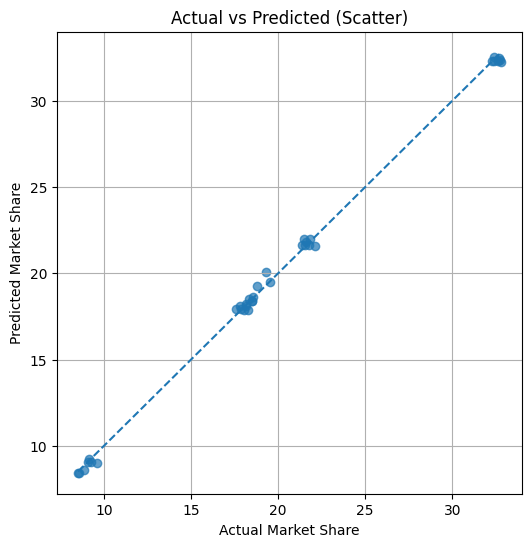

In [62]:
plt.figure(figsize=(6, 6))
plt.scatter(y_val, y_pred, alpha=0.7)
plt.plot(
    [y_val.min(), y_val.max()],
    [y_val.min(), y_val.max()],
    linestyle="--"
)
plt.xlabel("Actual Market Share")
plt.ylabel("Predicted Market Share")
plt.title("Actual vs Predicted (Scatter)")
plt.grid(True)
plt.show()


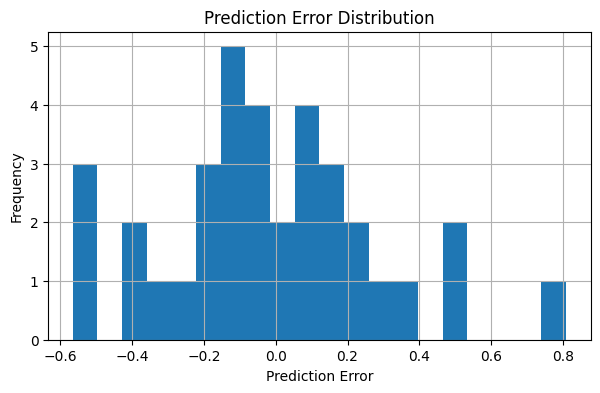

In [63]:
errors = y_pred - y_val

plt.figure(figsize=(7, 4))
plt.hist(errors, bins=20)
plt.title("Prediction Error Distribution")
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


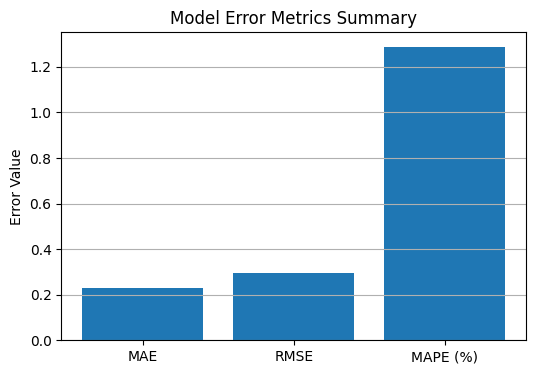

In [64]:
metrics = {
    "MAE": mae,
    "RMSE": rmse,
    "MAPE (%)": mape
}

plt.figure(figsize=(6, 4))
plt.bar(metrics.keys(), metrics.values())
plt.title("Model Error Metrics Summary")
plt.ylabel("Error Value")
plt.grid(axis="y")
plt.show()


In [66]:
# ==============================
# SAVE NEW MODEL AS "LATEST"
# ==============================

import joblib
import os

MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

latest_model_path = f"{MODEL_DIR}/lgb_market_share_latest.pkl"

joblib.dump(lgb_model, latest_model_path)

print(f"✅ New model saved as LATEST at:\n{latest_model_path}")
print("ℹ️ Previous models are preserved.")


✅ New model saved as LATEST at:
models/lgb_market_share_latest.pkl
ℹ️ Previous models are preserved.


In [67]:
# ==============================
# SAVE ENCODER & FEATURES (LATEST)
# ==============================

joblib.dump(le, f"{MODEL_DIR}/product_label_encoder_latest.pkl")
joblib.dump(FEATURES, f"{MODEL_DIR}/model_features_latest.pkl")

print("✅ Encoder and feature list saved as LATEST versions.")


✅ Encoder and feature list saved as LATEST versions.


In [68]:
# ==============================
# LOAD LATEST MODEL
# ==============================

lgb_model = joblib.load(f"{MODEL_DIR}/lgb_market_share_latest.pkl")
le = joblib.load(f"{MODEL_DIR}/product_label_encoder_latest.pkl")
FEATURES = joblib.load(f"{MODEL_DIR}/model_features_latest.pkl")

print("✅ Latest model, encoder, and features loaded.")


✅ Latest model, encoder, and features loaded.
